In [368]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pymysql
from sqlalchemy import create_engine, URL
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

In [369]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score )
from xgboost import XGBClassifier

In [370]:

env_path = Path.cwd().parent / 'config.env'

print(env_path)
print(env_path.exists())   # this must print True

load_dotenv(env_path, override=True)

print({
    'DB_USER': os.getenv('DB_USER') is not None,
    'DB_PASSWORD': os.getenv('DB_PASSWORD') is not None,
    'DB_HOST': os.getenv('DB_HOST') is not None,
    'DB_NAME': os.getenv('DB_NAME') is not None
})

c:\Users\BIMLESH KUMAR SAH\Desktop\YouTube Data Science\Customer-Churn-Analytics\config.env
True
{'DB_USER': True, 'DB_PASSWORD': True, 'DB_HOST': True, 'DB_NAME': True}


In [371]:
db_url = URL.create(
    drivername='mysql+pymysql',
    username=os.environ['DB_USER'],
    password=os.environ['DB_PASSWORD'],
    host=os.environ['DB_HOST'],
    database=os.environ['DB_NAME']
)

engine = create_engine(db_url)

df = pd.read_sql('SELECT * FROM vw_dashboard_fact', engine)

In [372]:
df.head(5)

,customer_id,gender,senior_citizen,partner,dependents,tenure,contract,internet_service,payment_method,monthly_charges,total_charges,churn,churn_flag
0,0002-ORFBO,Female,0,Yes,Yes,9,One year,DSL,Mailed check,65.6,593.30,No,0
1,0003-MKNFE,Male,0,No,No,9,Month-to-month,DSL,Mailed check,59.9,542.40,No,0
2,0004-TLHLJ,Male,0,No,No,4,Month-to-month,Fiber optic,Electronic check,73.9,280.85,Yes,1
3,0011-IGKFF,Male,1,Yes,No,13,Month-to-month,Fiber optic,Electronic check,98.0,1237.85,Yes,1
4,0013-EXCHZ,Female,1,Yes,No,3,Month-to-month,Fiber optic,Mailed check,83.9,267.40,Yes,1


In [373]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       7032 non-null   object 
 1   gender            7032 non-null   object 
 2   senior_citizen    7032 non-null   int64  
 3   partner           7032 non-null   object 
 4   dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   contract          7032 non-null   object 
 7   internet_service  7032 non-null   object 
 8   payment_method    7032 non-null   object 
 9   monthly_charges   7032 non-null   float64
 10  total_charges     7032 non-null   float64
 11  churn             7032 non-null   object 
 12  churn_flag        7032 non-null   int64  
dtypes: float64(2), int64(3), object(8)
memory usage: 714.3+ KB


In [374]:
df.shape

(7032, 13)

In [375]:
df.describe()

,senior_citizen,tenure,monthly_charges,total_charges,churn_flag
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [376]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'contract', 'internet_service', 'payment_method',
       'monthly_charges', 'total_charges', 'churn', 'churn_flag'],
      dtype='object')

In [377]:
df.isnull().sum()

customer_id         0
gender              0
senior_citizen      0
partner             0
dependents          0
tenure              0
contract            0
internet_service    0
payment_method      0
monthly_charges     0
total_charges       0
churn               0
churn_flag          0
dtype: int64

In [378]:
df.duplicated().sum()

np.int64(0)

In [379]:
df['churn'].value_counts()

churn
No     5163
Yes    1869
Name: count, dtype: int64

In [380]:
round(df['churn'].value_counts(normalize=True)*100,2)

churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

In [381]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'contract', 'internet_service', 'payment_method',
       'monthly_charges', 'total_charges', 'churn', 'churn_flag'],
      dtype='object')

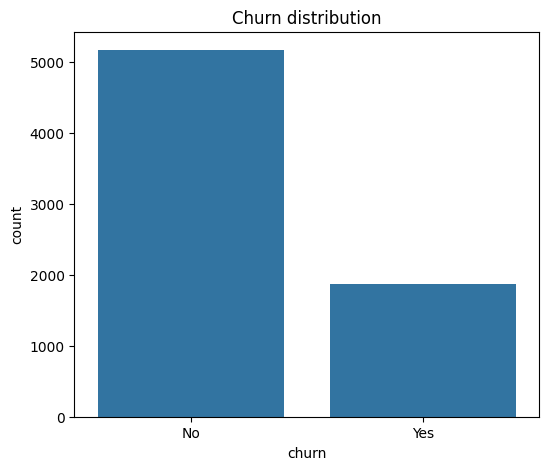

In [382]:
plt.figure(figsize=(6,5))
sns.countplot(data = df, x='churn')
plt.title('Churn distribution')
plt.show()

senior_citizen	tenure	monthly_charges	total_charges	churn_flag

In [383]:
num_col = ['senior_citizen',	'tenure',	'monthly_charges',	'total_charges']

In [384]:
df['churn_flag'].head(5)

0    0
1    0
2    1
3    1
4    1
Name: churn_flag, dtype: int64

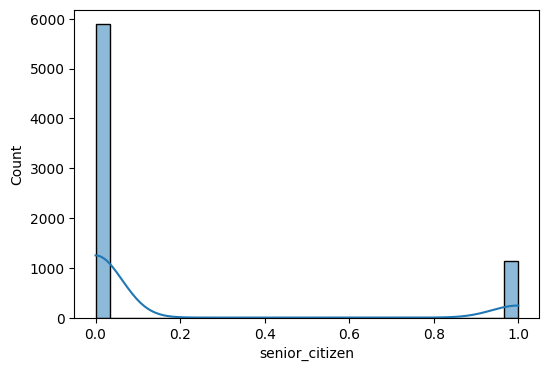

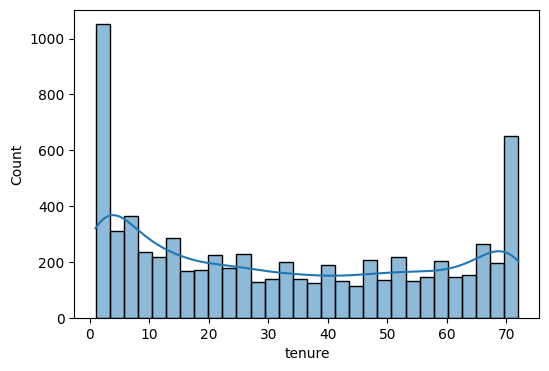

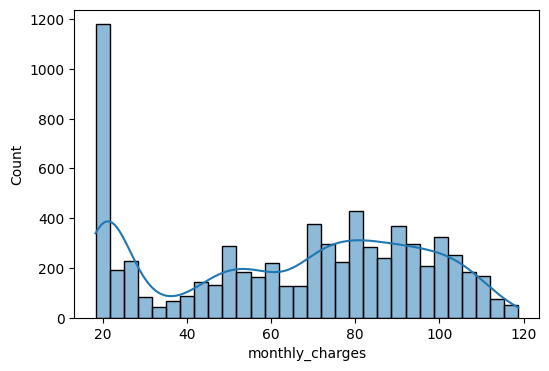

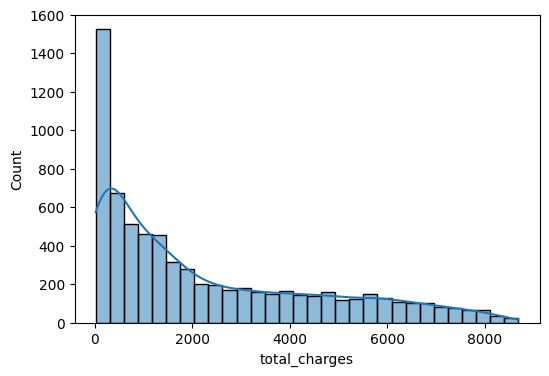

In [385]:
for i in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i], bins=30, kde = True)

In [386]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'contract', 'internet_service', 'payment_method',
       'monthly_charges', 'total_charges', 'churn', 'churn_flag'],
      dtype='object')

<Axes: >

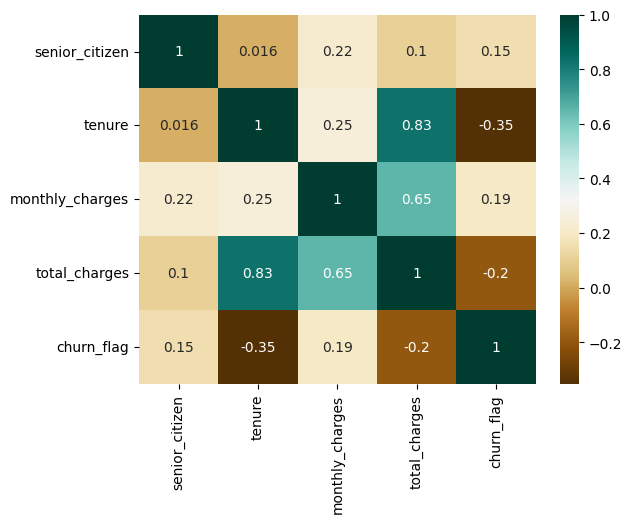

In [387]:
sns.heatmap(df.corr(numeric_only=True), annot = True,cmap='BrBG')

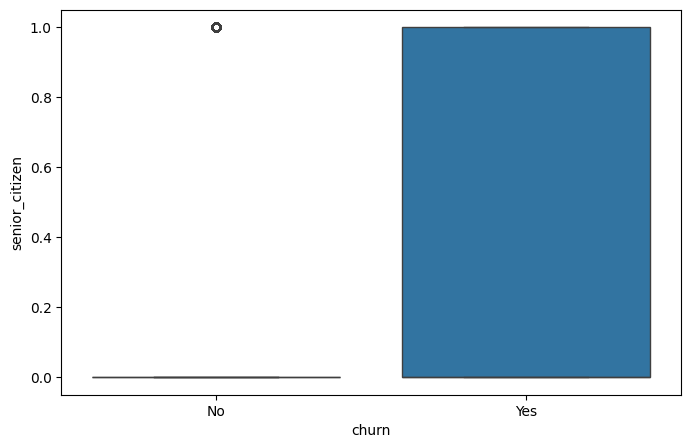

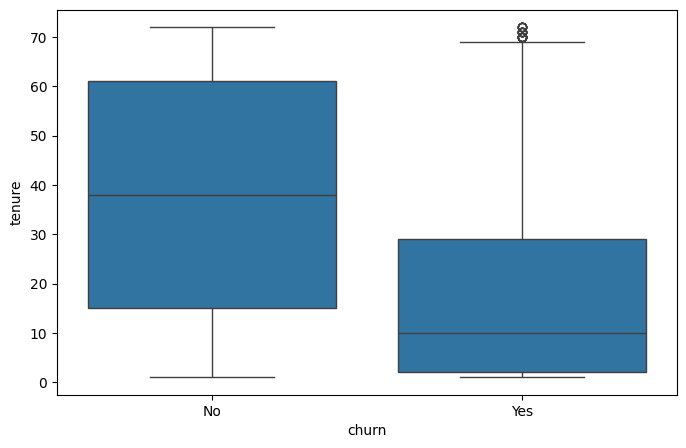

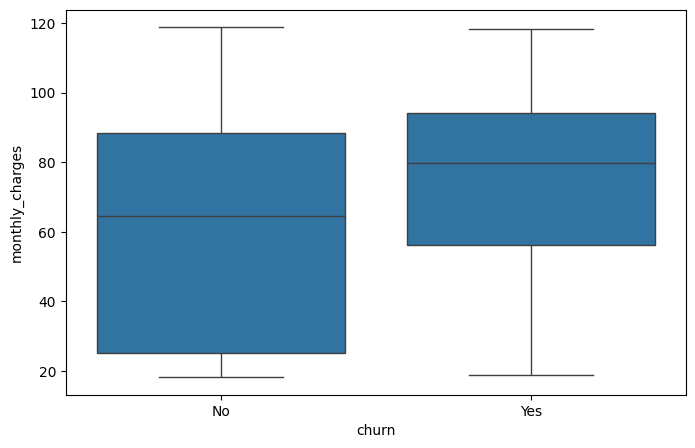

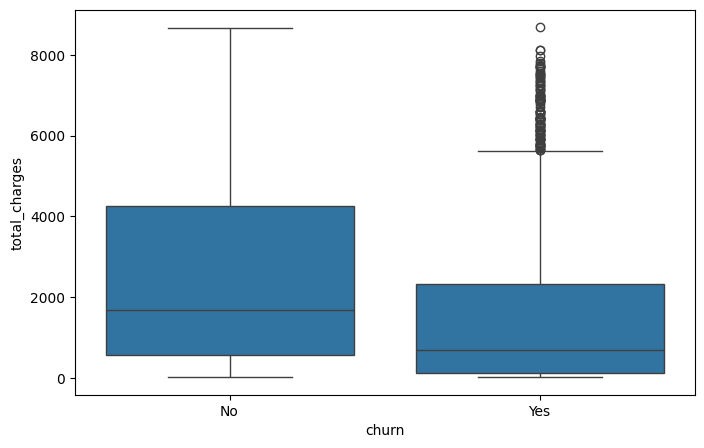

In [388]:
for i in num_col:
    plt.figure(figsize=(8,5))
    sns.boxplot(data = df, x='churn', y = i)

In [389]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'contract', 'internet_service', 'payment_method',
       'monthly_charges', 'total_charges', 'churn', 'churn_flag'],
      dtype='object')

In [390]:
cat_cols = ['gender', 'contract','internet_service', 'payment_method']

In [391]:
df['churn'].value_counts()

churn
No     5163
Yes    1869
Name: count, dtype: int64

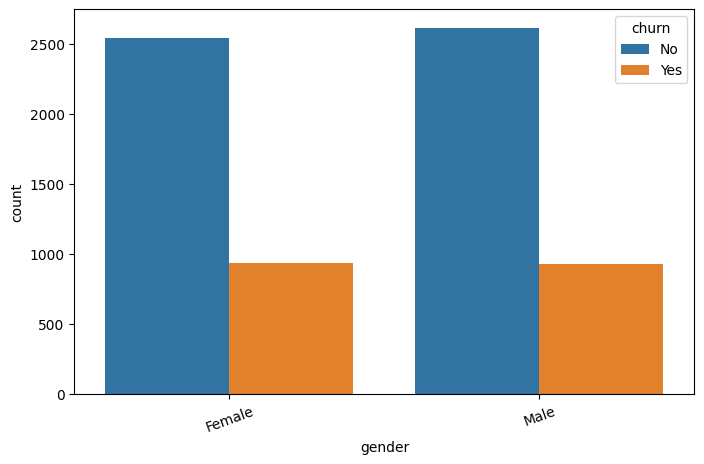

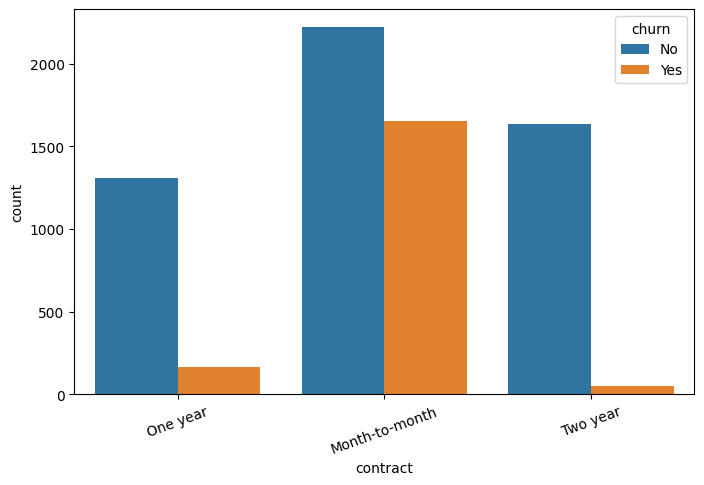

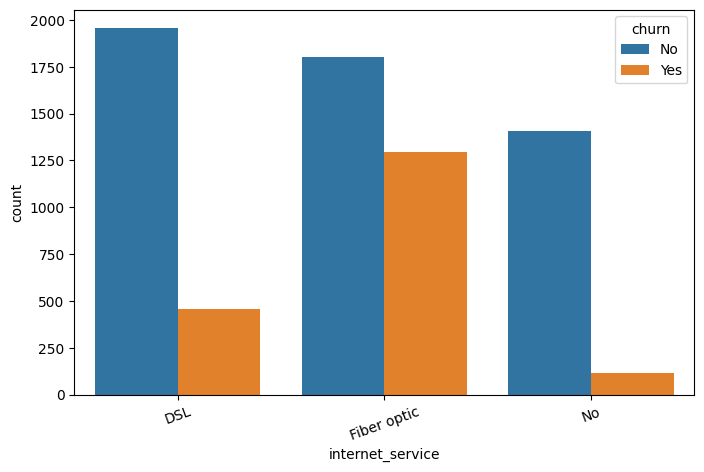

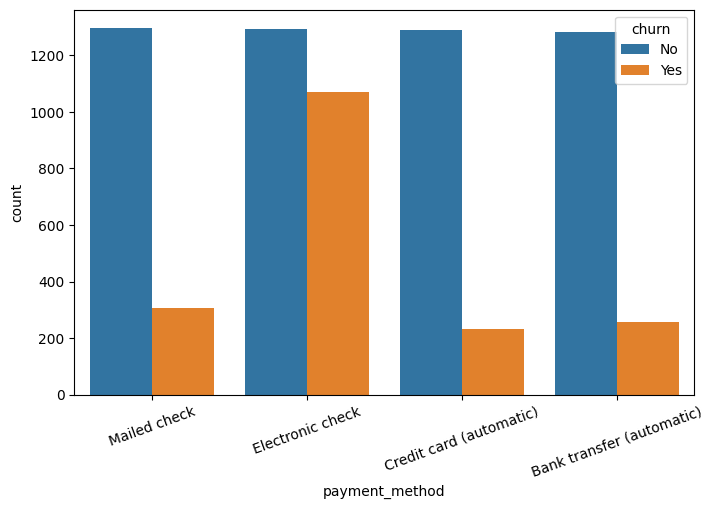

In [392]:
for i in cat_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data = df, x = i, hue='churn')
    plt.xticks(rotation = 20)

In [393]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'contract', 'internet_service', 'payment_method',
       'monthly_charges', 'total_charges', 'churn', 'churn_flag'],
      dtype='object')

In [394]:
contract_churn = pd.crosstab(df['contract'], df['churn'],normalize='index')*100

Text(0.5, 1.0, 'contract vs churn rate %')

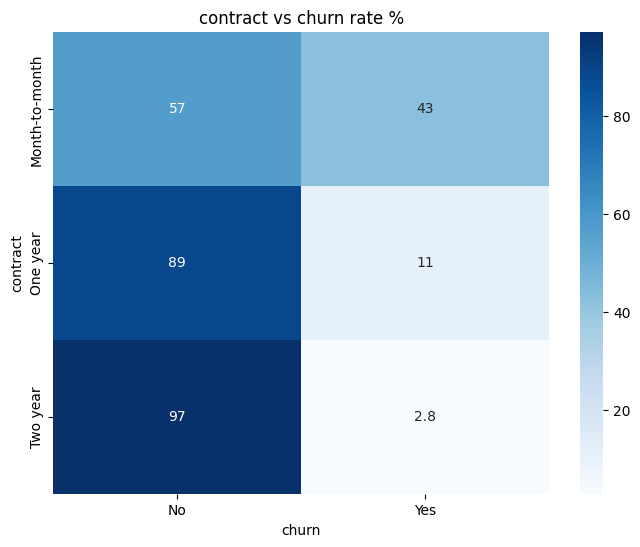

In [395]:
plt.figure(figsize=(8,6))
sns.heatmap(contract_churn, annot=True, cmap='Blues')
plt.title('contract vs churn rate %')

### Customer Segmentation

In [396]:
df['tenure'].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [397]:
def customer_segment(val):
    if val <= 12:
        return 'New'
    elif val <= 48:
        return 'Regular'
    else:
        return 'Loyal'

df['customer_segment'] = df['tenure'].apply(customer_segment)

In [398]:
df['customer_segment'].head()

0        New
1        New
2        New
3    Regular
4        New
Name: customer_segment, dtype: object

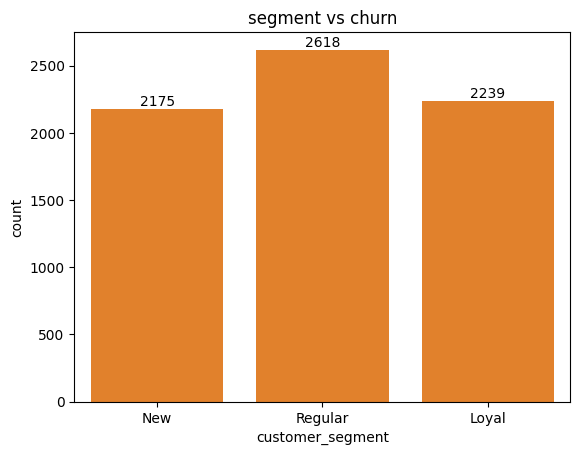

In [399]:
sns.countplot(x = df['customer_segment']).bar_label(sns.countplot(x = df['customer_segment'] ).containers[0])
plt.title('segment vs churn')
plt.show()

In [400]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'contract', 'internet_service', 'payment_method',
       'monthly_charges', 'total_charges', 'churn', 'churn_flag',
       'customer_segment'],
      dtype='object')

In [401]:
df['revenue_segment'] = pd.qcut(df['monthly_charges'], q = 3, labels=['Low', 'Medium', 'High'])

In [402]:
df['revenue_segment'].value_counts()

revenue_segment
Low       2345
Medium    2345
High      2342
Name: count, dtype: int64

<Axes: xlabel='revenue_segment', ylabel='count'>

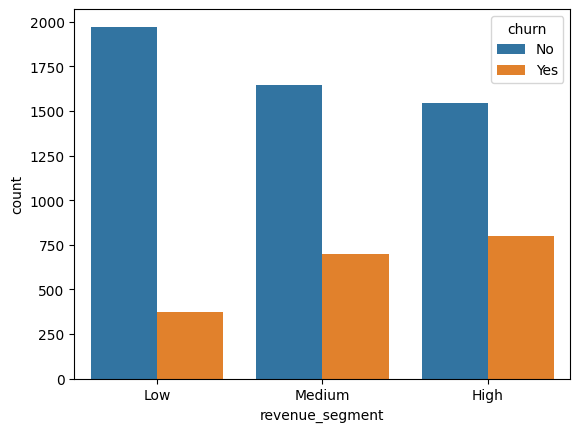

In [403]:
sns.countplot(data = df, x = 'revenue_segment', hue='churn')

In [404]:
df.groupby('revenue_segment')['churn'].value_counts(normalize=True) * 100

revenue_segment  churn
Low              No       84.093817
                 Yes      15.906183
Medium           No       70.234542
                 Yes      29.765458
High             No       65.926558
                 Yes      34.073442
Name: proportion, dtype: float64

In [405]:
# revenue lost
revenue_lost = df[
    df['churn']=='Yes'
]['monthly_charges'].sum()

revenue_lost

np.float64(139130.85)

In [406]:
# revnue lost by contract
df[df['churn']=='Yes'] \
.groupby('contract') \
['monthly_charges'] \
.sum() \
.sort_values(
    ascending=False
)

contract
Month-to-month    120847.10
One year           14118.45
Two year            4165.30
Name: monthly_charges, dtype: float64

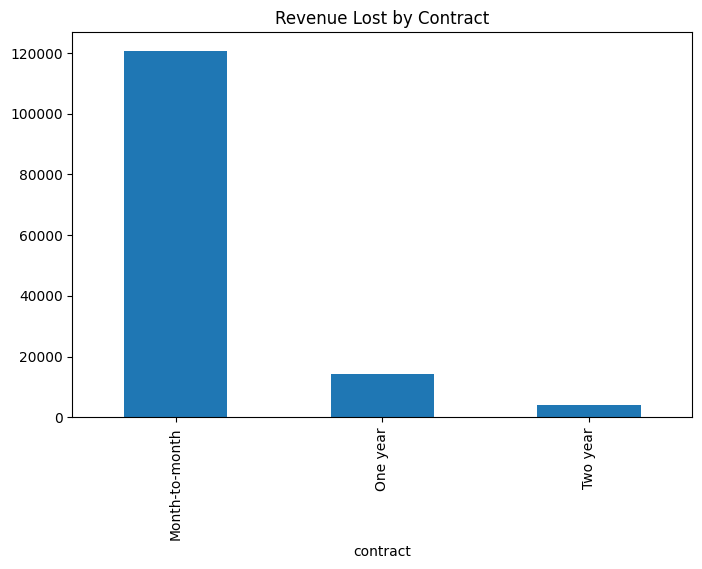

In [407]:
df[df['churn']=='Yes'] \
.groupby('contract') \
['monthly_charges'] \
.sum() \
.plot(
     kind='bar',
     figsize=(8,5)
)

plt.title("Revenue Lost by Contract")
plt.show()

In [408]:
df[['churn', 'churn_flag']].head(5)

,churn,churn_flag
0,No,0
1,No,0
2,Yes,1
3,Yes,1
4,Yes,1


## ML model

In [409]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'contract', 'internet_service', 'payment_method',
       'monthly_charges', 'total_charges', 'churn', 'churn_flag',
       'customer_segment', 'revenue_segment'],
      dtype='object')

In [410]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,contract,internet_service,payment_method,monthly_charges,total_charges,churn,churn_flag,customer_segment,revenue_segment
0,0002-ORFBO,Female,0,Yes,Yes,9,One year,DSL,Mailed check,65.6,593.30,No,0,New,Medium
1,0003-MKNFE,Male,0,No,No,9,Month-to-month,DSL,Mailed check,59.9,542.40,No,0,New,Medium
2,0004-TLHLJ,Male,0,No,No,4,Month-to-month,Fiber optic,Electronic check,73.9,280.85,Yes,1,New,Medium
3,0011-IGKFF,Male,1,Yes,No,13,Month-to-month,Fiber optic,Electronic check,98.0,1237.85,Yes,1,Regular,High
4,0013-EXCHZ,Female,1,Yes,No,3,Month-to-month,Fiber optic,Mailed check,83.9,267.40,Yes,1,New,Medium


In [411]:
features = [
    'gender',
    'senior_citizen',
    'partner',
    'dependents',
    'tenure',
    'contract',
    'internet_service',
    'payment_method',
    'monthly_charges',
    'total_charges'
]

In [412]:
df

,customer_id,gender,senior_citizen,partner,dependents,tenure,contract,internet_service,payment_method,monthly_charges,total_charges,churn,churn_flag,customer_segment,revenue_segment
0,0002-ORFBO,Female,0,Yes,Yes,9,One year,DSL,Mailed check,65.60,593.30,No,0,New,Medium
1,0003-MKNFE,Male,0,No,No,9,Month-to-month,DSL,Mailed check,59.90,542.40,No,0,New,Medium
2,0004-TLHLJ,Male,0,No,No,4,Month-to-month,Fiber optic,Electronic check,73.90,280.85,Yes,1,New,Medium
3,0011-IGKFF,Male,1,Yes,No,13,Month-to-month,Fiber optic,Electronic check,98.00,1237.85,Yes,1,Regular,High
4,0013-EXCHZ,Female,1,Yes,No,3,Month-to-month,Fiber optic,Mailed check,83.90,267.40,Yes,1,New,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,Female,0,No,No,13,One year,DSL,Mailed check,55.15,742.90,No,0,Regular,Medium
7028,9992-RRAMN,Male,0,Yes,No,22,Month-to-month,Fiber optic,Electronic check,85.10,1873.70,Yes,1,Regular,High
7029,9992-UJOEL,Male,0,No,No,2,Month-to-month,DSL,Mailed check,50.30,92.75,No,0,New,Low
7030,9993-LHIEB,Male,0,Yes,Yes,67,Two year,DSL,Mailed check,67.85,4627.65,No,0,Loyal,Medium


In [413]:
X = df[features]
y = df['churn_flag']

In [414]:
X = pd.get_dummies(X, drop_first=True)
X

,senior_citizen,tenure,monthly_charges,total_charges,gender_Male,partner_Yes,dependents_Yes,contract_One year,contract_Two year,internet_service_Fiber optic,internet_service_No,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,9,65.60,593.30,False,True,True,True,False,False,False,False,False,True
1,0,9,59.90,542.40,True,False,False,False,False,False,False,False,False,True
2,0,4,73.90,280.85,True,False,False,False,False,True,False,False,True,False
3,1,13,98.00,1237.85,True,True,False,False,False,True,False,False,True,False
4,1,3,83.90,267.40,False,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,13,55.15,742.90,False,False,False,True,False,False,False,False,False,True
7028,0,22,85.10,1873.70,True,True,False,False,False,True,False,False,True,False
7029,0,2,50.30,92.75,True,False,False,False,False,False,False,False,False,True
7030,0,67,67.85,4627.65,True,True,True,False,True,False,False,False,False,True


In [415]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [416]:
X_train.shape

(5625, 14)

In [417]:
X_test.shape

(1407, 14)

In [418]:
y_train.shape

(5625,)

In [419]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [420]:
X_train_scaled

array([[-0.4396068 ,  0.18427875, -1.47925404, ..., -0.52461513,
        -0.71022035, -0.54852422],
       [-0.4396068 ,  1.44338326,  1.15500801, ..., -0.52461513,
         1.40801373, -0.54852422],
       [ 2.27476009, -1.1966746 ,  0.30020328, ..., -0.52461513,
         1.40801373, -0.54852422],
       ...,
       [-0.4396068 ,  1.48399954,  0.55464905, ...,  1.90615927,
        -0.71022035, -0.54852422],
       [-0.4396068 , -0.3843491 , -1.50253666, ..., -0.52461513,
        -0.71022035,  1.82307357],
       [-0.4396068 ,  0.54982522,  1.34293201, ..., -0.52461513,
        -0.71022035, -0.54852422]], shape=(5625, 14))

# logistic model

In [421]:
Logistic_model = LogisticRegression()
Logistic_model.fit(X_train_scaled,y_train)

LogisticRegression()

In [422]:
LM_y_pred = Logistic_model.predict(X_test_scaled)

In [423]:
metrics = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'F1 Score': f1_score,

}

In [424]:
for name, metric_function in metrics.items():
    print(f'{name}: {metric_function(y_test, LM_y_pred):.3f}')


Accuracy: 0.796
Precision: 0.640
Recall: 0.532
F1 Score: 0.581


In [425]:
print(classification_report(y_test, LM_y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [426]:
LM_y_prob = Logistic_model.predict_proba(X_test_scaled)[:, 1]

In [427]:
roc_auc_score(y_test,LM_y_prob)

np.float64(0.8357452723234855)

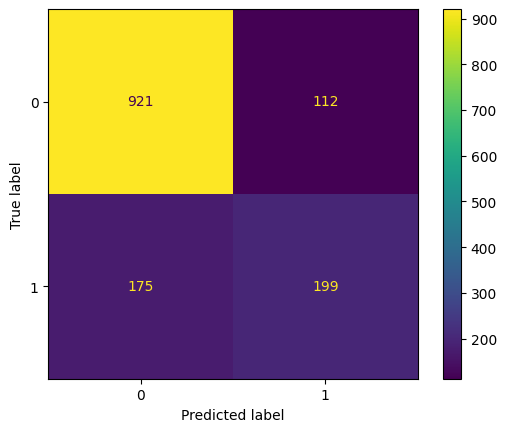

In [442]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    LM_y_pred
)
plt.show()

In [443]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': Logistic_model.coef_[0]
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

coef_df.sort_values(
    'Abs_Coefficient',
    ascending=False
).head(15)

,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.307593,1.307593
8,contract_Two year,-0.649909,0.649909
3,total_charges,0.629393,0.629393
9,internet_service_Fiber optic,0.448347,0.448347
10,internet_service_No,-0.354060,0.354060
7,contract_One year,-0.321587,0.321587
12,payment_method_Electronic check,0.220989,0.220989
0,senior_citizen,0.126058,0.126058
6,dependents_Yes,-0.055667,0.055667
2,monthly_charges,-0.052790,0.052790


# Random foreset

In [428]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [429]:
rf_y_pred = rf_model.predict(X_test)

In [430]:
accuracy_score(y_test,rf_y_pred)

0.7697228144989339

In [431]:
print(classification_report(y_test,rf_y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.58      0.47      0.52       374

    accuracy                           0.77      1407
   macro avg       0.70      0.67      0.68      1407
weighted avg       0.76      0.77      0.76      1407



In [432]:
rf_prob = rf_model.predict_proba(X_test)[:,1]
roc_auc_score(y_test,rf_prob)

np.float64(0.7995623049008392)

In [433]:
xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
)

xgb_model.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [434]:
xgb_y_pred = xgb_model.predict(X_test)


In [435]:
print(classification_report(y_test,xgb_y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [436]:
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [437]:
roc_auc_score(y_test,xgb_prob)

np.float64(0.8366330867469755)

In [438]:
cm = confusion_matrix(y_test, xgb_y_pred)
cm

array([[925, 108],
       [185, 189]])

<Axes: >

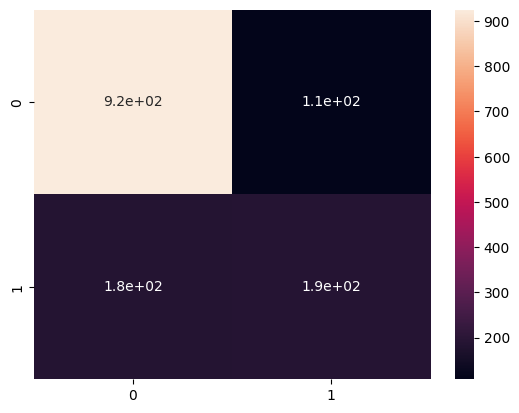

In [439]:
sns.heatmap(cm,annot=True)

In [441]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance.sort_values(
    'Importance',
    ascending=False
).head(15)

,Feature,Importance
3,total_charges,0.261232
2,monthly_charges,0.245377
1,tenure,0.204795
9,internet_service_Fiber optic,0.051739
12,payment_method_Electronic check,0.044233
8,contract_Two year,0.034863
4,gender_Male,0.026565
7,contract_One year,0.026120
5,partner_Yes,0.021932
0,senior_citizen,0.020954


In [440]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, LM_y_pred),
        accuracy_score(y_test, rf_y_pred),
        accuracy_score(y_test, xgb_y_pred)
    ],

    "F1":[
        f1_score(y_test, LM_y_pred),
        f1_score(y_test, rf_y_pred),
        f1_score(y_test, xgb_y_pred)
    ],

    "ROC_AUC":[
        roc_auc_score(y_test, LM_y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,F1,ROC_AUC
2,XGBoost,0.791756,0.563338,0.836633
0,Logistic Regression,0.796020,0.581022,0.835745
1,Random Forest,0.769723,0.520710,0.799562


In [444]:
import joblib

joblib.dump(
    Logistic_model,
    "logistic_churn_model.pkl"
)

['logistic_churn_model.pkl']

In [445]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [446]:
joblib.dump(
    X.columns.tolist(),
    "model_features.pkl"
)

['model_features.pkl']

In [447]:
model_info = {
    "model_name":"Logistic Regression",
    "accuracy":0.796,
    "f1_score":0.581,
    "roc_auc":0.836
}

joblib.dump(
    model_info,
    "model_info.pkl"
)

['model_info.pkl']